In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [21]:
DATADIR = "D:/NCKH/RSNA_58_studies/"
ROOT = Path(DATADIR)

In [22]:
train_df = pd.read_csv(ROOT / "train.csv")
train_series = pd.read_csv(ROOT / "train_series.csv")

In [23]:
display(train_df.head())

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,The study reveals normal knee joint alignment...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,"MRI of left Knee with \n-3-Plane Loc R'T, Sag ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,"In the medial compartment, there is longitudi...",1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
train_df.isnull().sum()

StudyInstanceUID    0
Report              0
ACL                 0
MCL                 0
Medial Meniscus     0
Lateral Meniscus    0
Medial OA           0
Lateral OA          0
PF OA               0
Effusion            0
Synovitis           0
Baker's             0
Contusion           0
Fracture            0
dtype: int64

In [25]:
train_series

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,0,Sagittal
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.12451507871565834868...,0,0,Coronal
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
3,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
4,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial
...,...,...,...,...,...
331,1.2.826.0.1.3680043.8.498.97274720257634584071...,1.2.826.0.1.3680043.8.498.12306898793869915364...,0,0,Axial
332,1.2.826.0.1.3680043.8.498.97274720257634584071...,1.2.826.0.1.3680043.8.498.17378665248295186489...,0,0,Sagittal
333,1.2.826.0.1.3680043.8.498.97274720257634584071...,1.2.826.0.1.3680043.8.498.26303375425736222633...,0,0,Sagittal
334,1.2.826.0.1.3680043.8.498.97274720257634584071...,1.2.826.0.1.3680043.8.498.92909718893560498250...,1,1,Axial


,StudyInstanceUID,Abnormalities,Total
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,"PF OA, Effusion",2.0
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,"Lateral Meniscus, PF OA, Synovitis",3.0
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,"Medial Meniscus, Medial OA, PF OA, Synovitis",4.0
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,Effusion,1.0
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,"ACL, Medial Meniscus",2.0
5,1.2.826.0.1.3680043.8.498.11548045715264151632...,"Effusion, Synovitis, Contusion",3.0
6,1.2.826.0.1.3680043.8.498.11557620559191469069...,"ACL, Lateral Meniscus, Lateral OA, Effusion",4.0
7,1.2.826.0.1.3680043.8.498.11771393824519892797...,"MCL, Contusion",2.0
8,1.2.826.0.1.3680043.8.498.11851412923016044948...,"Medial Meniscus, Lateral Meniscus, Medial OA, ...",6.0
9,1.2.826.0.1.3680043.8.498.11915937982684988073...,"Lateral Meniscus, Lateral OA, PF OA, Effusion,...",6.0


Đã xuất CSV: D:\NCKH\RSNA_58_studies\outputs\abnormalities_per_study.csv


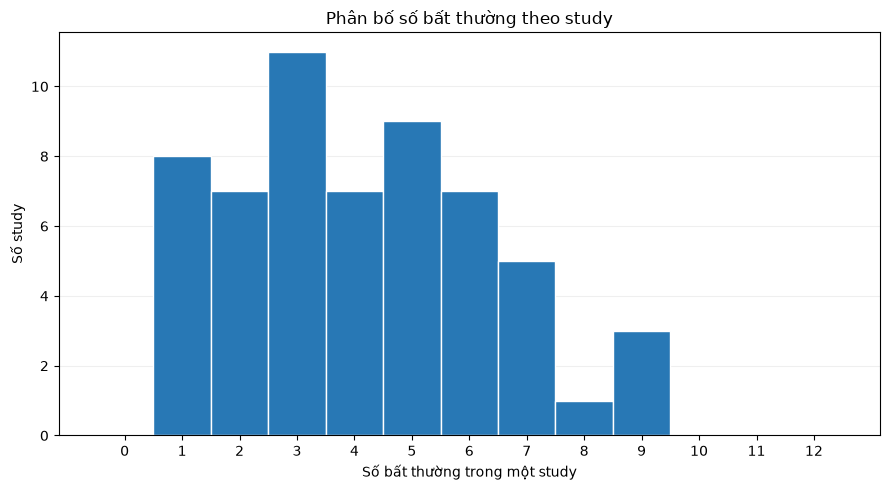

Đã lưu histogram: D:\NCKH\RSNA_58_studies\outputs\abnormalities_per_study_histogram.png


In [26]:
label_cols = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
 ]

result = pd.DataFrame()
result["StudyInstanceUID"] = train_df["StudyInstanceUID"]

result["Abnormalities"] = train_df[label_cols].apply(
    lambda row: ", ".join(
        label for label in label_cols if row[label] == 1
    ),
    axis=1
)

result["Total"] = train_df[label_cols].sum(axis=1)

output_dir = ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)
csv_path = output_dir / "abnormalities_per_study.csv"
result.to_csv(csv_path, index=False, encoding="utf-8-sig")

display(result)
print(f"Đã xuất CSV: {csv_path}")

# Histogram phân bố số bất thường trên mỗi study
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(-0.5, len(label_cols) + 1.5, 1)
ax.hist(result["Total"], bins=bins, color="#2878B5", edgecolor="white")
ax.set_xticks(range(len(label_cols) + 1))
ax.set_xlabel("Số bất thường trong một study")
ax.set_ylabel("Số study")
ax.set_title("Phân bố số bất thường theo study")
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()

histogram_path = output_dir / "abnormalities_per_study_histogram.png"
fig.savefig(histogram_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Đã lưu histogram: {histogram_path}")

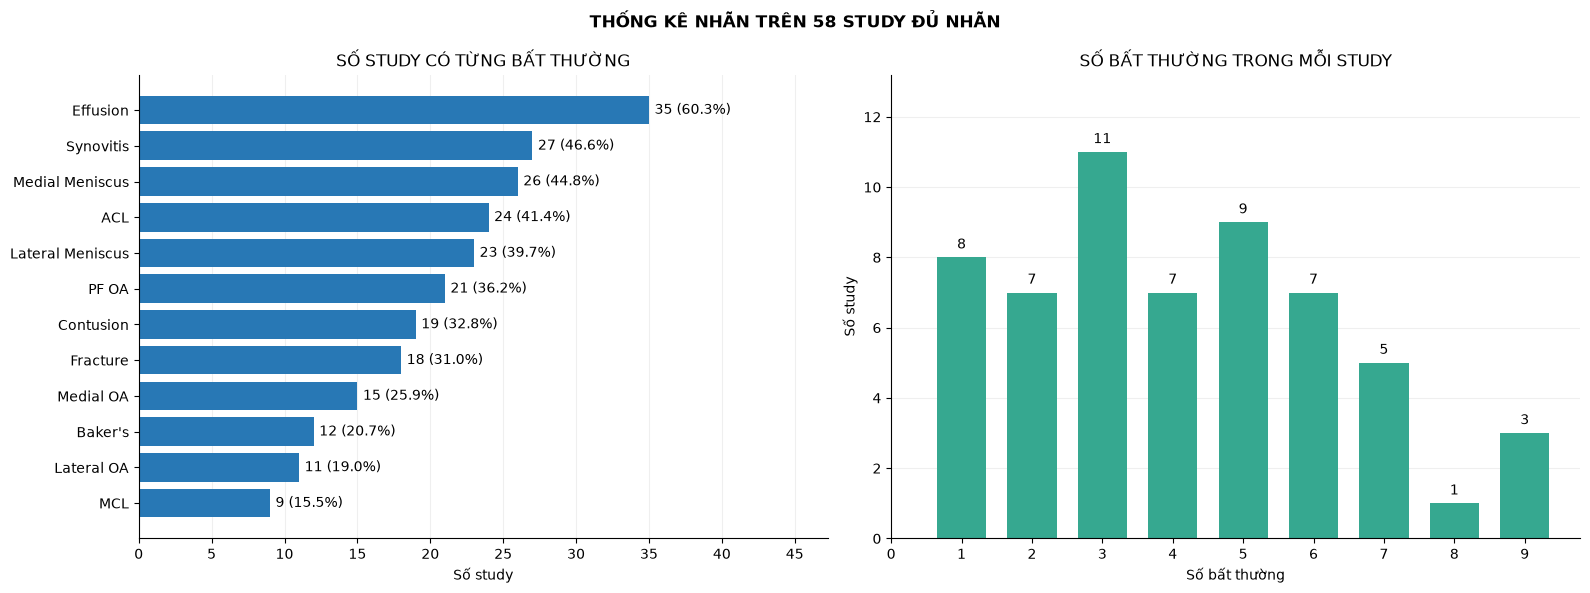

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Chỉ thống kê các study có đủ 12 nhãn
has_full_labels = train_df[label_cols].notna().all(axis=1)

result["Total"] = (
    train_df[label_cols]
    .sum(axis=1, min_count=len(label_cols))
    .astype("Int64")
)

result.loc[~has_full_labels, "Abnormalities"] = "Chưa đủ nhãn"

# 2. Chuẩn bị dữ liệu thống kê
labeled = train_df.loc[has_full_labels, label_cols]

if labeled.empty:
    print("Không có study đủ nhãn để vẽ biểu đồ.")
else:
    # Số study dương tính với từng bất thường
    label_counts = labeled.eq(1).sum().sort_values()

    # Số study có 0, 1, 2, ... bất thường
    total_counts = (
        result.loc[has_full_labels, "Total"]
        .value_counts()
        .sort_index()
    )

    # 3. Vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    bars = axes[0].barh(
        label_counts.index,
        label_counts.values,
        color="#2878B5"
    )
    axes[0].bar_label(
        bars,
        labels=[
            f"{n} ({n / len(labeled):.1%})"
            for n in label_counts.values
        ],
        padding=4
    )
    axes[0].set_xlim(0, max(1, label_counts.max()) * 1.35)
    axes[0].set_title("SỐ STUDY CÓ TỪNG BẤT THƯỜNG")
    axes[0].set_xlabel("Số study")
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].grid(axis="x", alpha=0.2)

    bars = axes[1].bar(
        total_counts.index.astype(int),
        total_counts.values,
        color="#36A890",
        width=0.7
    )
    axes[1].bar_label(bars, padding=4)
    axes[1].set_xticks(range(int(total_counts.index.max()) + 1))
    axes[1].set_ylim(0, total_counts.max() * 1.2)
    axes[1].set_title("SỐ BẤT THƯỜNG TRONG MỖI STUDY")
    axes[1].set_xlabel("Số bất thường")
    axes[1].set_ylabel("Số study")
    axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].grid(axis="y", alpha=0.2)

    for ax in axes:
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(
        f"THỐNG KÊ NHÃN TRÊN {len(labeled)} STUDY ĐỦ NHÃN",
        fontweight="bold"
    )
    plt.tight_layout()

    fig.savefig(
        output_dir / "thong_ke_bat_thuong.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [28]:
counts = train_df[label_cols].sum().sort_values(ascending=False)

print(counts)

Effusion            35.0
Synovitis           27.0
Medial Meniscus     26.0
ACL                 24.0
Lateral Meniscus    23.0
PF OA               21.0
Contusion           19.0
Fracture            18.0
Medial OA           15.0
Baker's             12.0
Lateral OA          11.0
MCL                  9.0
dtype: float64


In [ ]:
# import ipywidgets as widgets
# from IPython.display import display, clear_output



# label_cols = [
#     "ACL",
#     "MCL",
#     "Medial Meniscus",
#     "Lateral Meniscus",
#     "Medial OA",
#     "Lateral OA",
#     "PF OA",
#     "Effusion",
#     "Synovitis",
#     "Baker's",
#     "Contusion",
#     "Fracture"
# ]

# # =========================
# # 2. Tạo giao diện
# # =========================

# current_index = 0

# output = widgets.Output()

# prev_button = widgets.Button(
#     description="← Previous"
# )

# next_button = widgets.Button(
#     description="Next →"
# )

# index_label = widgets.Label()


# # =========================
# # 3. Hàm hiển thị study
# # =========================

# def show_study(index):
#     global current_index

#     current_index = index

#     row = train_df.iloc[index]

#     abnormalities = [
#         label
#         for label in label_cols
#         if row[label] == 1
#     ]

#     with output:
#         clear_output(wait=True)

#         print("=" * 90)
#         print(f"STUDY {index + 1} / {len(train_df)}")
#         print("=" * 90)

#         print("\nUID:")
#         print(row["StudyInstanceUID"])

#         print(f"\nSố bất thường: {len(abnormalities)}")

#         print("\nBất thường:")
#         if abnormalities:
#             for abnormality in abnormalities:
#                 print(f"  • {abnormality}")
#         else:
#             print("  Không có bất thường")

#         print("\n" + "-" * 90)

#         print("REPORT:")
#         print("-" * 90)

#         print(row["Report"])

#         print("\n" + "=" * 90)

#     index_label.value = f"Study {index + 1} / {len(train_df)}"

#     prev_button.disabled = index == 0
#     next_button.disabled = index == len(train_df) - 1


# # =========================
# # 4. Xử lý nút
# # =========================

# def on_previous_clicked(b):
#     if current_index > 0:
#         show_study(current_index - 1)


# def on_next_clicked(b):
#     if current_index < len(train_df) - 1:
#         show_study(current_index + 1)


# prev_button.on_click(on_previous_clicked)
# next_button.on_click(on_next_clicked)


# # =========================
# # 5. Hiển thị
# # =========================

# display(
#     widgets.HBox([
#         prev_button,
#         index_label,
#         next_button
#     ])
# )

# display(output)

# show_study(0)

Output()

In [30]:
# from pathlib import Path
# import pandas as pd
# import pydicom
# from pydicom.multival import MultiValue
# from IPython.display import display

# # =========================================================
# # 1. ĐƯỜNG DẪN
# # Cấu trúc dự kiến:
# # RSNA_58_studies/
# #   train_series.csv
# #   train_series/
# #     StudyInstanceUID/
# #       SeriesInstanceUID/
# #         *.dcm
# # =========================================================
# ROOT = Path(r"D:\NCKH\RSNA_58_studies")
# DICOM_ROOT = ROOT / "train_series"

# OUTPUT_DIR = ROOT / "outputs"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# OUTPUT_CSV = OUTPUT_DIR / "series_technical_metadata.csv"

# if not DICOM_ROOT.is_dir():
#     raise FileNotFoundError(
#         f"Không tìm thấy thư mục ảnh: {DICOM_ROOT}\n"
#         "Hãy sửa DICOM_ROOT thành thư mục chứa các study."
#     )

# series_df = pd.read_csv(
#     ROOT / "train_series.csv",
#     dtype={
#         "StudyInstanceUID": str,
#         "SeriesInstanceUID": str,
#     }
# )

# required = {"StudyInstanceUID", "SeriesInstanceUID"}
# if not required.issubset(series_df.columns):
#     raise ValueError("CSV thiếu cột StudyInstanceUID hoặc SeriesInstanceUID.")

# if series_df.duplicated(["StudyInstanceUID", "SeriesInstanceUID"]).any():
#     raise ValueError("CSV có dòng trùng StudyInstanceUID + SeriesInstanceUID.")

# # =========================================================
# # 2. CÁC THÔNG TIN KỸ THUẬT CẦN LẤY
# # Key: tên cột xuất CSV
# # Value: keyword trong DICOM
# # =========================================================
# FIELDS = {
#     # Tên và loại chuỗi chụp
#     "SeriesDescription": "SeriesDescription",
#     "ProtocolName": "ProtocolName",
#     "SequenceName": "SequenceName",
#     "ScanningSequence": "ScanningSequence",
#     "SequenceVariant": "SequenceVariant",
#     "ScanOptions": "ScanOptions",
#     "MRAcquisitionType": "MRAcquisitionType",
#     "ImageType": "ImageType",
#     "SeriesNumber": "SeriesNumber",
#     "Modality": "Modality",

#     # Thông số xung
#     "TR_ms": "RepetitionTime",
#     "TE_ms": "EchoTime",
#     "TI_ms": "InversionTime",
#     "FlipAngle_deg": "FlipAngle",
#     "EchoTrainLength": "EchoTrainLength",
#     "EchoNumbers": "EchoNumbers",
#     "NumberOfAverages": "NumberOfAverages",
#     "PixelBandwidth_Hz_per_pixel": "PixelBandwidth",
#     "ImagingFrequency_MHz": "ImagingFrequency",
#     "MagneticFieldStrength_T": "MagneticFieldStrength",

#     # Kích thước và hình học ảnh
#     "Rows": "Rows",
#     "Columns": "Columns",
#     "PixelSpacing_mm": "PixelSpacing",
#     "SliceThickness_mm": "SliceThickness",
#     "SpacingBetweenSlices_mm": "SpacingBetweenSlices",
#     "AcquisitionMatrix": "AcquisitionMatrix",
#     "ReconstructionDiameter_mm": "ReconstructionDiameter",
#     "InPlanePhaseEncodingDirection": "InPlanePhaseEncodingDirection",
#     "PercentSampling": "PercentSampling",
#     "PercentPhaseFieldOfView": "PercentPhaseFieldOfView",
#     "ImageOrientationPatient": "ImageOrientationPatient",
#     "RepresentativeInstanceNumber": "InstanceNumber",
#     "RepresentativeNumberOfFrames": "NumberOfFrames",

#     # Máy và coil
#     "Manufacturer": "Manufacturer",
#     "ManufacturerModelName": "ManufacturerModelName",
#     "SoftwareVersions": "SoftwareVersions",
#     "ReceiveCoilName": "ReceiveCoilName",
#     "TransmitCoilName": "TransmitCoilName",

#     # Vùng chụp và chất tương phản nếu được ghi
#     "BodyPartExamined": "BodyPartExamined",
#     "PatientPosition": "PatientPosition",
#     "Laterality": "Laterality",
#     "ImageLaterality": "ImageLaterality",
#     "ContrastBolusAgent": "ContrastBolusAgent",
# }

# READ_TAGS = list(set(
#     FIELDS.values()
# ) | {"StudyInstanceUID", "SeriesInstanceUID"})


# def csv_value(value):
#     """Chuyển giá trị DICOM sang dạng dễ lưu trong CSV."""
#     if value is None:
#         return ""
#     if isinstance(value, (list, tuple, MultiValue)):
#         return " | ".join(str(item) for item in value)
#     return str(value)


# # =========================================================
# # 3. ĐỌC MỘT HEADER ĐẠI DIỆN HỢP LỆ CỦA MỖI SERIES
# # Không đọc pixel nên không cần giải nén ảnh.
# # Nếu file đầu lỗi hoặc sai UID, thử file tiếp theo.
# # =========================================================
# records = []

# for index, (_, row) in enumerate(series_df.iterrows(), start=1):
#     study_uid = row["StudyInstanceUID"]
#     series_uid = row["SeriesInstanceUID"]
#     series_dir = DICOM_ROOT / study_uid / series_uid

#     record = row.to_dict()
#     record.update({column: "" for column in FIELDS})
#     record.update({
#         "SeriesDirectory": str(series_dir),
#         "CandidateFileCount": 0,
#         "RepresentativeDICOM": "",
#         "ReadStatus": "",
#         "SkippedFilesBeforeRepresentative": 0,
#         "ReadNotes": "",
#     })

#     if not series_dir.is_dir():
#         record["ReadStatus"] = "MISSING_FOLDER"
#         records.append(record)
#         continue

#     # Nhận file .dcm, .dicom hoặc file không có phần mở rộng.
#     files = sorted(
#         path for path in series_dir.rglob("*")
#         if path.is_file()
#         and path.suffix.lower() in {".dcm", ".dicom", ""}
#     )
#     record["CandidateFileCount"] = len(files)

#     if not files:
#         record["ReadStatus"] = "NO_DICOM_CANDIDATES"
#         records.append(record)
#         continue

#     errors = []

#     for path in files:
#         try:
#             ds = pydicom.dcmread(
#                 path,
#                 stop_before_pixels=True,
#                 specific_tags=READ_TAGS,
#             )

#             # Không ghép nhầm header của study/series khác.
#             actual_study = str(getattr(ds, "StudyInstanceUID", ""))
#             actual_series = str(getattr(ds, "SeriesInstanceUID", ""))

#             if actual_study != study_uid or actual_series != series_uid:
#                 raise ValueError("UID trong DICOM không khớp dòng CSV")

#             for column, keyword in FIELDS.items():
#                 record[column] = csv_value(getattr(ds, keyword, None))

#             record["RepresentativeDICOM"] = str(path)
#             record["ReadStatus"] = "OK"
#             break

#         except Exception as exc:
#             errors.append(f"{path.name}: {type(exc).__name__}: {exc}")

#     if not record["ReadStatus"]:
#         record["ReadStatus"] = "NO_VALID_HEADER"

#     record["SkippedFilesBeforeRepresentative"] = len(errors)
#     record["ReadNotes"] = "; ".join(errors[:3])
#     records.append(record)

#     if index % 20 == 0 or index == len(series_df):
#         print(f"Đã xử lý {index}/{len(series_df)} series")


# # =========================================================
# # 4. XUẤT CSV
# # utf-8-sig giúp Excel đọc tiếng Việt.
# # Các giá trị không có trong header được để trống.
# # =========================================================
# metadata_df = pd.DataFrame(records)

# metadata_df.to_csv(
#     OUTPUT_CSV,
#     index=False,
#     encoding="utf-8-sig",
# )

# print("\nĐã xuất:", OUTPUT_CSV)
# print("Số study:", metadata_df["StudyInstanceUID"].nunique())
# print("Số series:", len(metadata_df))
# print("\nTrạng thái đọc:")
# print(metadata_df["ReadStatus"].value_counts().to_string())

# preview_cols = [
#     "SeriesDescription",
#     "Fluid_Sensitive",
#     "Fat_Suppression",
#     "Anatomical_Plane",
#     "MRAcquisitionType",
#     "TR_ms",
#     "TE_ms",
#     "TI_ms",
#     "FlipAngle_deg",
#     "SliceThickness_mm",
#     "CandidateFileCount",
#     "ReadStatus",
# ]

# display(
#     metadata_df[
#         [column for column in preview_cols if column in metadata_df.columns]
#     ].head(20)
# )

# failed = metadata_df[metadata_df["ReadStatus"] != "OK"]
# if not failed.empty:
#     print("\nCác series cần kiểm tra:")
#     display(failed[
#         ["StudyInstanceUID", "SeriesInstanceUID", "ReadStatus", "SeriesDirectory"]
#     ])

In [31]:
series_df = pd.read_csv(
    ROOT / "outputs" / "series_technical_metadata.csv"
)


In [32]:
print(series_df.shape)
print(series_df.dtypes)

(336, 54)
StudyInstanceUID                        str
SeriesInstanceUID                       str
Fluid_Sensitive                       int64
Fat_Suppression                       int64
Anatomical_Plane                        str
SeriesDescription                       str
ProtocolName                        float64
SequenceName                            str
ScanningSequence                        str
SequenceVariant                         str
ScanOptions                             str
MRAcquisitionType                       str
ImageType                               str
SeriesNumber                          int64
Modality                                str
TR_ms                               float64
TE_ms                               float64
TI_ms                               float64
FlipAngle_deg                       float64
EchoTrainLength                     float64
EchoNumbers                         float64
NumberOfAverages                    float64
PixelBandwidth_Hz_per_

Số series bị loại do thiếu/sai kích thước: 0


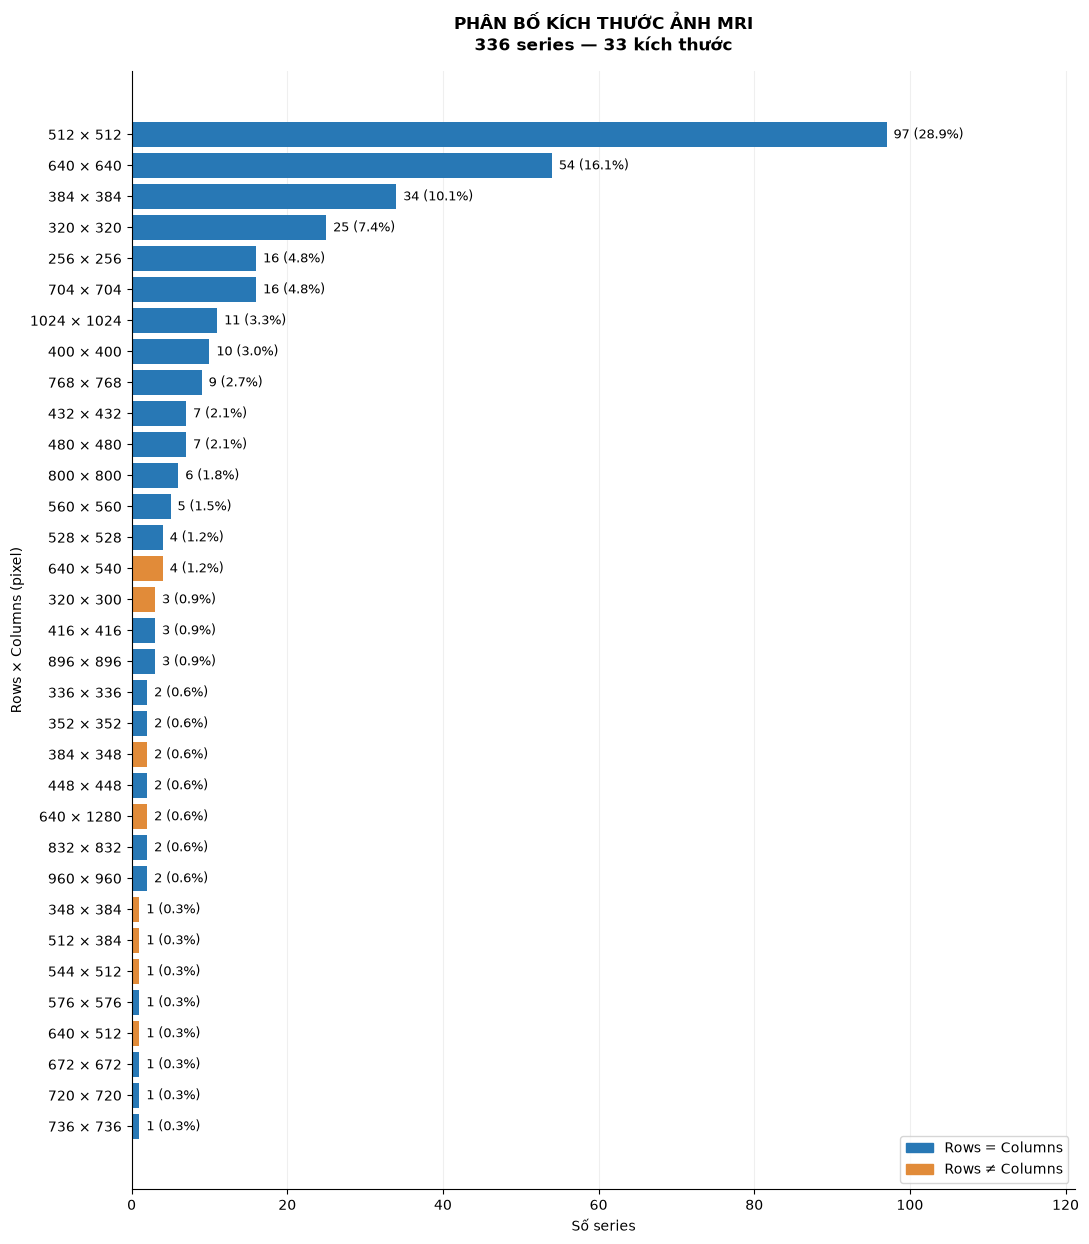

Đã lưu: D:\NCKH\RSNA_58_studies\outputs\thong_ke_rows_columns.png


,Kich_thuoc,So_series,Ty_le_%
0,512 × 512,97,28.87
1,640 × 640,54,16.07
2,384 × 384,34,10.12
3,320 × 320,25,7.44
4,256 × 256,16,4.76
5,704 × 704,16,4.76
6,1024 × 1024,11,3.27
7,400 × 400,10,2.98
8,768 × 768,9,2.68
9,432 × 432,7,2.08


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Dùng dữ liệu đã đọc từ series_technical_metadata.csv
df_size = series_df.drop_duplicates(subset="SeriesInstanceUID").copy()

for col in ["Rows", "Columns"]:
    df_size[col] = pd.to_numeric(df_size[col], errors="coerce")

# Chỉ giữ kích thước là số nguyên dương
valid = (
    df_size[["Rows", "Columns"]].notna().all(axis=1)
    & (df_size[["Rows", "Columns"]] > 0).all(axis=1)
    & (df_size[["Rows", "Columns"]] % 1 == 0).all(axis=1)
)

print(f"Số series bị loại do thiếu/sai kích thước: {(~valid).sum()}")

df_size = df_size.loc[valid].copy()
df_size[["Rows", "Columns"]] = df_size[["Rows", "Columns"]].astype(int)

if df_size.empty:
    raise ValueError("Không có dữ liệu Rows và Columns hợp lệ.")

# Đếm số series theo từng cặp kích thước
size_counts = (
    df_size.groupby(["Rows", "Columns"])
    .size()
    .reset_index(name="So_series")
    .sort_values("So_series", ascending=False, kind="stable")
    .reset_index(drop=True)
)

size_counts["Kich_thuoc"] = (
    size_counts["Rows"].astype(str)
    + " × "
    + size_counts["Columns"].astype(str)
)
size_counts["Ty_le_%"] = (
    size_counts["So_series"] / size_counts["So_series"].sum() * 100
)

# Vẽ biểu đồ
colors = [
    "#2878B5" if row == col else "#E18B39"
    for row, col in zip(size_counts["Rows"], size_counts["Columns"])
]

fig, ax = plt.subplots(
    figsize=(11, max(6, len(size_counts) * 0.38))
)

bars = ax.barh(
    size_counts["Kich_thuoc"],
    size_counts["So_series"],
    color=colors
)
ax.invert_yaxis()

ax.bar_label(
    bars,
    labels=[
        f"{n} ({pct:.1f}%)"
        for n, pct in zip(
            size_counts["So_series"], size_counts["Ty_le_%"]
        )
    ],
    padding=5,
    fontsize=9
)

ax.set_xlim(0, size_counts["So_series"].max() * 1.25)
ax.set_xlabel("Số series")
ax.set_ylabel("Rows × Columns (pixel)")
ax.set_title(
    "PHÂN BỐ KÍCH THƯỚC ẢNH MRI\n"
    f"{len(df_size)} series — {len(size_counts)} kích thước",
    fontweight="bold",
    pad=15
)

ax.legend(
    handles=[
        Patch(color="#2878B5", label="Rows = Columns"),
        Patch(color="#E18B39", label="Rows ≠ Columns")
    ],
    loc="lower right"
)

ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

# Lưu biểu đồ vào thư mục outputs
output_path = ROOT / "outputs" / "thong_ke_rows_columns.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()
print(f"Đã lưu: {output_path}")

display(
    size_counts[["Kich_thuoc", "So_series", "Ty_le_%"]]
    .style.format({"Ty_le_%": "{:.2f}"})
)

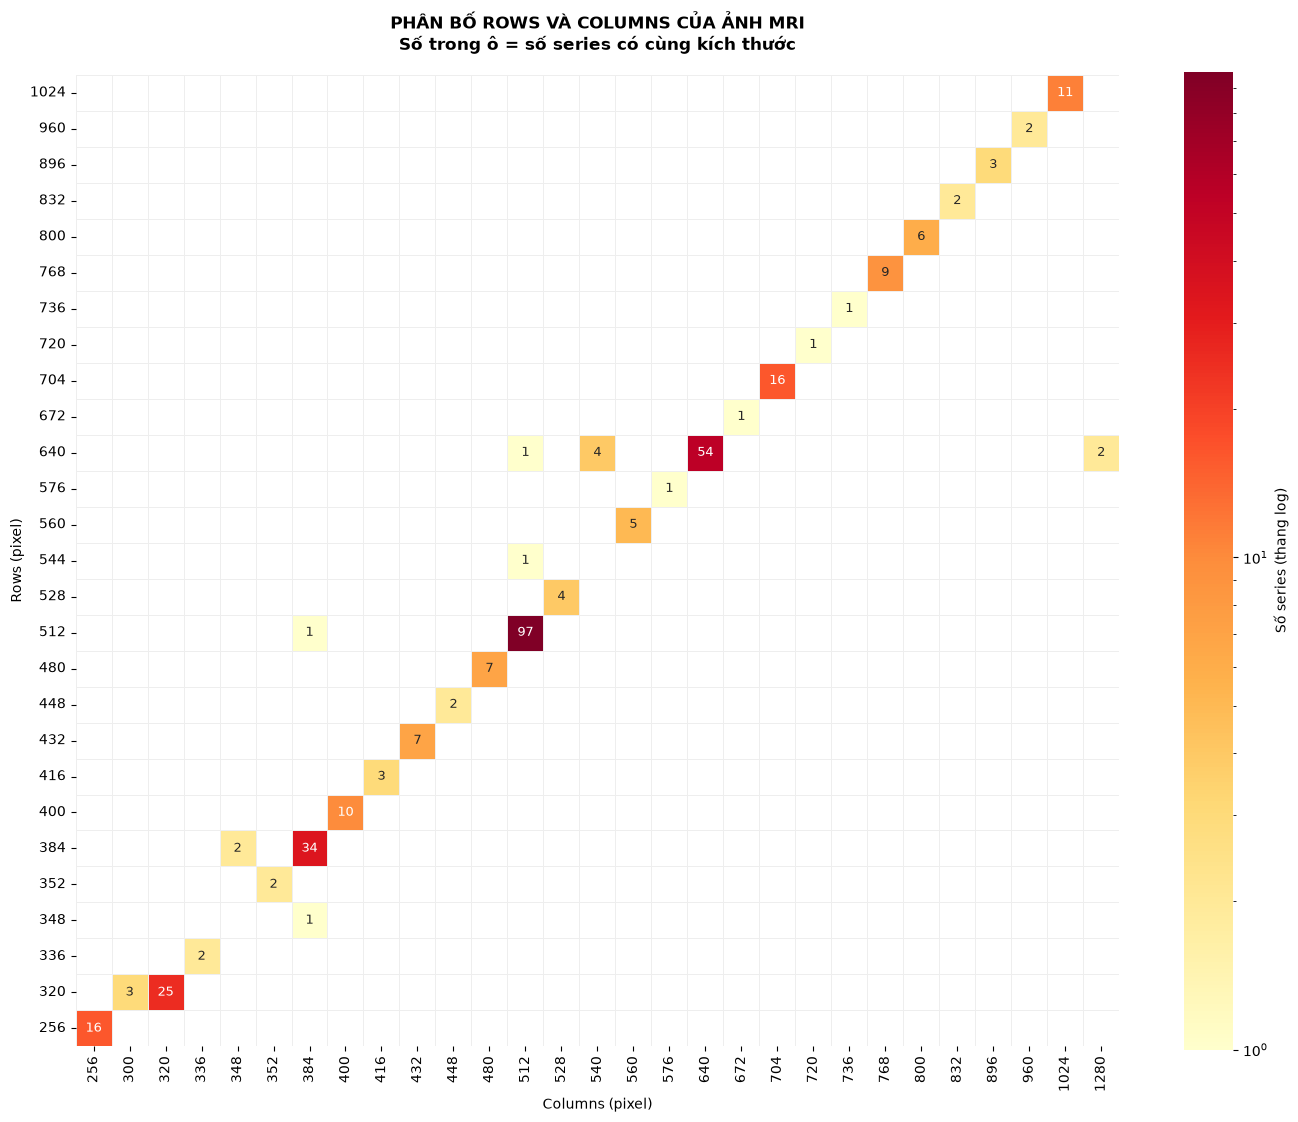

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Bảng tần suất: hàng là Rows, cột là Columns
size_table = pd.crosstab(
    df_size["Rows"],
    df_size["Columns"]
).sort_index(ascending=False).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    size_table,
    mask=size_table.eq(0),       # Ẩn các cặp không xuất hiện
    annot=True,                 # Ghi số series trong mỗi ô
    fmt="d",
    cmap="YlOrRd",
    norm=LogNorm(
        vmin=1,
        vmax=max(2, int(size_table.to_numpy().max()))
    ),
    linewidths=0.4,
    linecolor="#eeeeee",
    square=True,
    cbar_kws={"label": "Số series (thang log)"},
    annot_kws={"fontsize": 9},
    ax=ax
)

ax.set_title(
    "PHÂN BỐ ROWS VÀ COLUMNS CỦA ẢNH MRI\n"
    "Số trong ô = số series có cùng kích thước",
    fontweight="bold",
    pad=18
)
ax.set_xlabel("Columns (pixel)")
ax.set_ylabel("Rows (pixel)")
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()

output_path = ROOT / "outputs" / "heatmap_rows_columns.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

Tổng số study: 58
Tổng số series: 336
Ít nhất: 4 series/study
Nhiều nhất: 9 series/study
Trung bình: 5.79 series/study
Trung vị: 5 series/study


,StudyInstanceUID,So_series
0,1.2.826.0.1.3680043.8.498.10170898615867673028...,9
1,1.2.826.0.1.3680043.8.498.11548045715264151632...,9
2,1.2.826.0.1.3680043.8.498.11382021393803389951...,9
3,1.2.826.0.1.3680043.8.498.12606657226568558340...,9
4,1.2.826.0.1.3680043.8.498.17844546765907321649...,9
5,1.2.826.0.1.3680043.8.498.65708905118633339771...,9
6,1.2.826.0.1.3680043.8.498.41600498783384864111...,8
7,1.2.826.0.1.3680043.8.498.82166943552764439138...,8
8,1.2.826.0.1.3680043.8.498.27437263843446879932...,7
9,1.2.826.0.1.3680043.8.498.10306159113324811538...,7


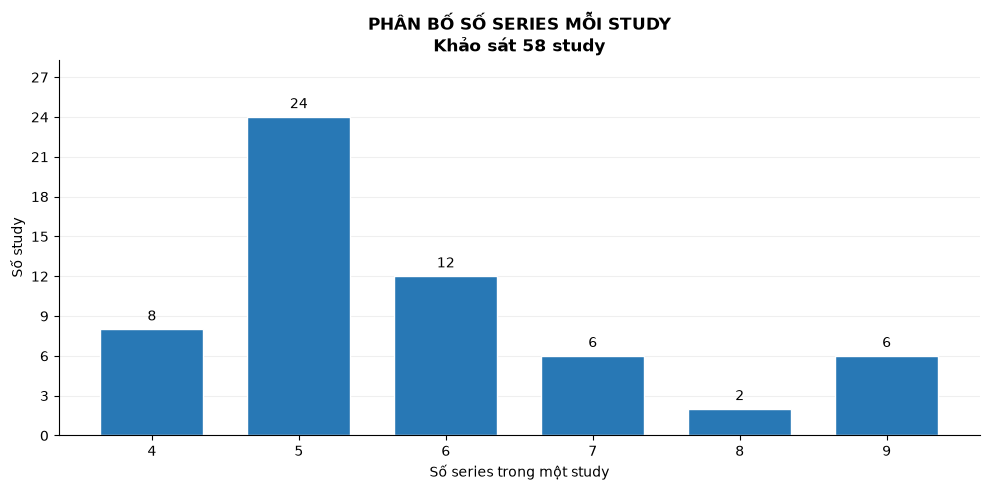

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Đếm số series riêng biệt trong mỗi study
series_per_study = (
    series_df.groupby("StudyInstanceUID")["SeriesInstanceUID"]
    .nunique()
    .reset_index(name="So_series")
    .sort_values("So_series", ascending=False)
    .reset_index(drop=True)
)

if series_per_study.empty:
    raise ValueError("Không có study để thống kê.")

# Thống kê tổng quan
counts = series_per_study["So_series"]

print(f"Tổng số study: {len(series_per_study)}")
print(f"Tổng số series: {counts.sum()}")
print(f"Ít nhất: {counts.min()} series/study")
print(f"Nhiều nhất: {counts.max()} series/study")
print(f"Trung bình: {counts.mean():.2f} series/study")
print(f"Trung vị: {counts.median():g} series/study")

# Bảng chi tiết từng study
display(series_per_study)

# Ví dụ: có bao nhiêu study chứa 4 series, 5 series, ...
distribution = counts.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    distribution.index,
    distribution.values,
    color="#2878B5",
    edgecolor="white",
    width=0.7
)

ax.bar_label(bars, padding=4)
ax.set_xticks(distribution.index)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(0, distribution.max() * 1.18)

ax.set_xlabel("Số series trong một study")
ax.set_ylabel("Số study")
ax.set_title(
    f"PHÂN BỐ SỐ SERIES MỖI STUDY\n"
    f"Khảo sát {len(series_per_study)} study",
    fontweight="bold"
)

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

# Lưu kết quả
output_dir = ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / "so_series_moi_study.png",
    dpi=300,
    bbox_inches="tight"
)
series_per_study.to_csv(
    output_dir / "so_series_moi_study.csv",
    index=False
)

plt.show()

THỐNG KÊ THEO MẶT PHẲNG


,So_series,So_study,Ty_le_series_%
Plane,,,
Axial,81,58,24.11
Coronal,119,58,35.42
Sagittal,136,58,40.48


Tổng số study: 58
Có đủ 3 mặt phẳng: 58/58 (100.0%)
Chưa ghi nhận đủ 3 mặt phẳng: 0


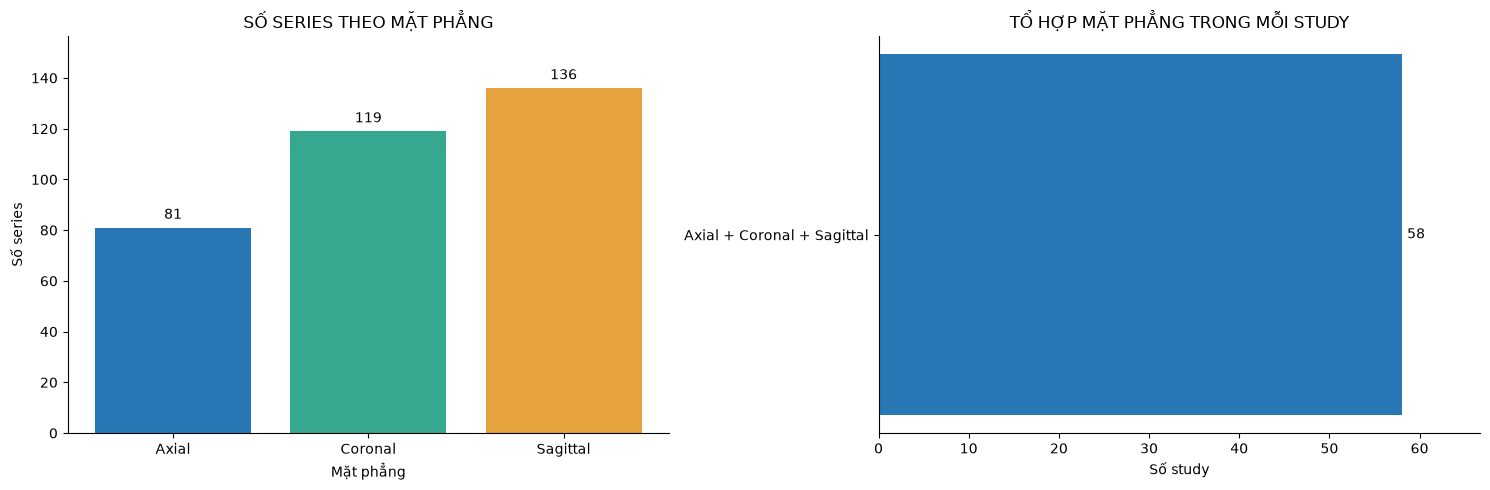

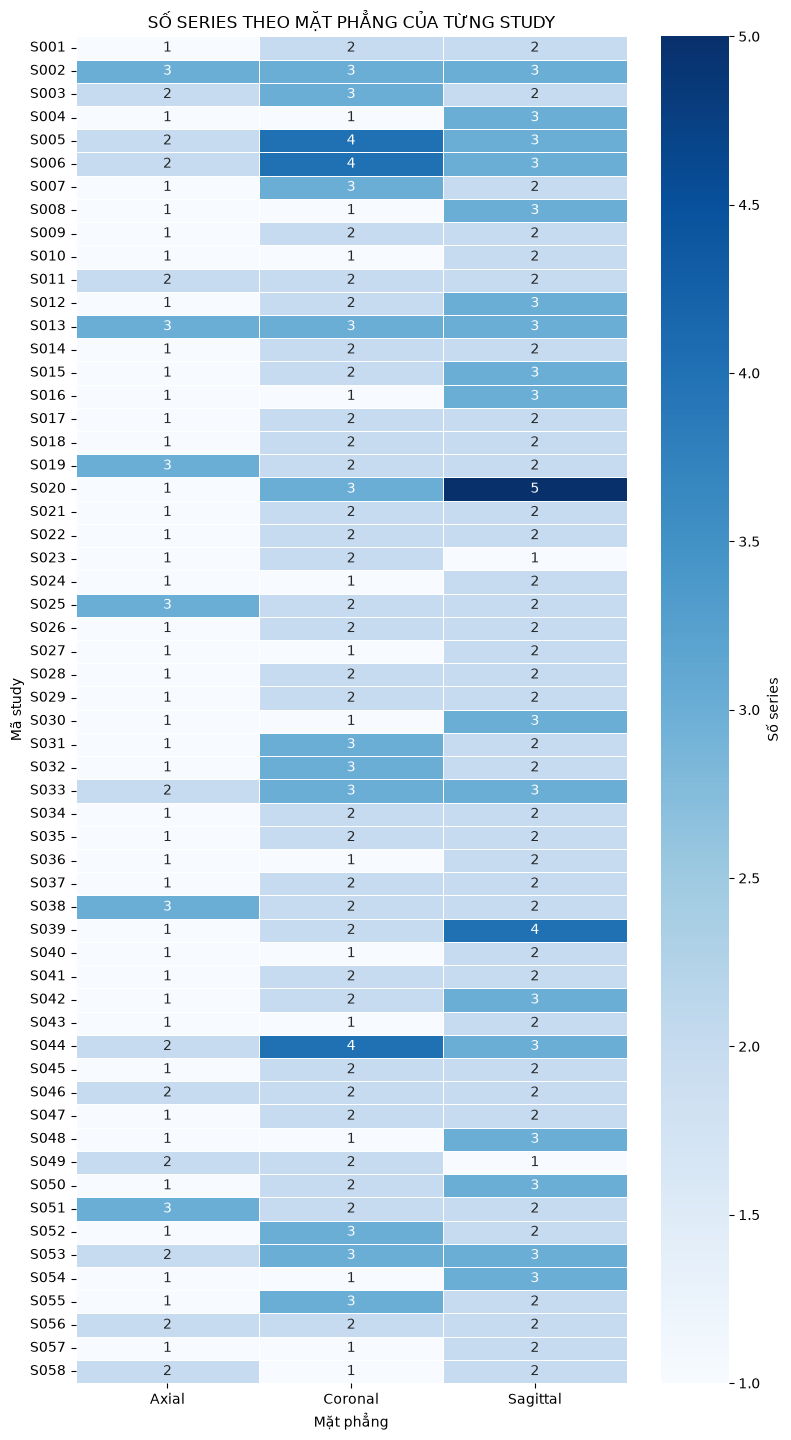

Plane,StudyInstanceUID,Study_code,Axial,Coronal,Sagittal,So_mat_phang,Du_3_mat_phang,Mat_phang_thieu
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,S001,1,2,2,3,True,Không thiếu
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,S002,3,3,3,3,True,Không thiếu
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,S003,2,3,2,3,True,Không thiếu
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,S004,1,1,3,3,True,Không thiếu
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,S005,2,4,3,3,True,Không thiếu
5,1.2.826.0.1.3680043.8.498.11548045715264151632...,S006,2,4,3,3,True,Không thiếu
6,1.2.826.0.1.3680043.8.498.11557620559191469069...,S007,1,3,2,3,True,Không thiếu
7,1.2.826.0.1.3680043.8.498.11771393824519892797...,S008,1,1,3,3,True,Không thiếu
8,1.2.826.0.1.3680043.8.498.11851412923016044948...,S009,1,2,2,3,True,Không thiếu
9,1.2.826.0.1.3680043.8.498.11915937982684988073...,S010,1,1,2,3,True,Không thiếu


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

planes = ["Axial", "Coronal", "Sagittal"]

# Mỗi series được đếm một lần
plane_df = (
    series_df.dropna(subset=["StudyInstanceUID", "SeriesInstanceUID"])
    .drop_duplicates(subset=["StudyInstanceUID", "SeriesInstanceUID"])
    .copy()
)

if plane_df.empty:
    raise ValueError("Không có series để khảo sát.")

# Chuẩn hóa tên mặt phẳng; giữ riêng dữ liệu thiếu/khác
plane_names = (
    plane_df["Anatomical_Plane"]
    .astype("string")
    .str.strip()
    .str.lower()
)

plane_df["Plane"] = (
    plane_names.map({
        "axial": "Axial",
        "coronal": "Coronal",
        "sagittal": "Sagittal"
    })
    .fillna("Khác / thiếu")
)

# 1. Số series và số study có từng mặt phẳng
plane_order = planes.copy()
if plane_df["Plane"].eq("Khác / thiếu").any():
    plane_order.append("Khác / thiếu")

summary = (
    plane_df.groupby("Plane")
    .agg(
        So_series=("SeriesInstanceUID", "size"),
        So_study=("StudyInstanceUID", "nunique")
    )
    .reindex(plane_order, fill_value=0)
)
summary["Ty_le_series_%"] = (
    summary["So_series"] / len(plane_df) * 100
)

print("THỐNG KÊ THEO MẶT PHẲNG")
display(summary.round(2))

# 2. Số series của từng mặt phẳng trong mỗi study
study_planes = pd.crosstab(
    plane_df["StudyInstanceUID"],
    plane_df["Plane"]
).reindex(columns=plane_order, fill_value=0)

has_plane = study_planes[planes].gt(0)
study_planes["So_mat_phang"] = has_plane.sum(axis=1)
study_planes["Du_3_mat_phang"] = has_plane.all(axis=1)

study_planes["Mat_phang_thieu"] = has_plane.apply(
    lambda row: ", ".join(p for p in planes if not row[p]) or "Không thiếu",
    axis=1
)

n_studies = len(study_planes)
n_complete = int(study_planes["Du_3_mat_phang"].sum())

print(f"Tổng số study: {n_studies}")
print(
    f"Có đủ 3 mặt phẳng: {n_complete}/{n_studies} "
    f"({n_complete / n_studies:.1%})"
)
print(f"Chưa ghi nhận đủ 3 mặt phẳng: {n_studies - n_complete}")

# 3. Các tổ hợp mặt phẳng xuất hiện trong study
combinations = has_plane.apply(
    lambda row: " + ".join(p for p in planes if row[p])
    or "Không rõ mặt phẳng",
    axis=1
)
combination_counts = combinations.value_counts()

# 4. Vẽ biểu đồ tổng quan
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(
    summary.index,
    summary["So_series"],
    color=["#2878B5", "#36A890", "#E6A23C", "#999999"][:len(summary)]
)
axes[0].bar_label(bars, padding=4)
axes[0].set_title("SỐ SERIES THEO MẶT PHẲNG")
axes[0].set_xlabel("Mặt phẳng")
axes[0].set_ylabel("Số series")
axes[0].margins(y=0.15)

bars = axes[1].barh(
    combination_counts.index,
    combination_counts.values,
    color="#2878B5"
)
axes[1].bar_label(bars, padding=4)
axes[1].invert_yaxis()
axes[1].set_title("TỔ HỢP MẶT PHẲNG TRONG MỖI STUDY")
axes[1].set_xlabel("Số study")
axes[1].margins(x=0.15)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

output_dir = ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(
    output_dir / "tong_quan_mat_phang.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 5. Heatmap: mỗi dòng là một study, số trong ô là số series
# Dùng mã ngắn để biểu đồ dễ đọc; UID đầy đủ nằm trong bảng bên dưới
study_planes = study_planes.sort_index()
study_planes.insert(
    0, "Study_code",
    [f"S{i:03d}" for i in range(1, n_studies + 1)]
)

heatmap_data = study_planes.set_index("Study_code")[plane_order]

fig, ax = plt.subplots(
    figsize=(8, max(6, n_studies * 0.25))
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Số series"},
    ax=ax
)

ax.set_title("SỐ SERIES THEO MẶT PHẲNG CỦA TỪNG STUDY")
ax.set_xlabel("Mặt phẳng")
ax.set_ylabel("Mã study")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
fig.savefig(
    output_dir / "mat_phang_tung_study.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Bảng đối chiếu mã ngắn với StudyInstanceUID
display(study_planes.reset_index())

study_planes.reset_index().to_csv(
    output_dir / "mat_phang_tung_study.csv",
    index=False,
    encoding="utf-8-sig"
)

Tổng số series: 336


,0,1,Thiếu / không hợp lệ,Tỷ lệ 1 / có dữ liệu (%)
Fluid_Sensitive,144,192,0,57.14
Fat_Suppression,144,192,0,57.14



Series có đủ hai cờ: 336/336
Hai cờ giống nhau: 336 series (100.0%)
Hai cờ khác nhau: 0 series


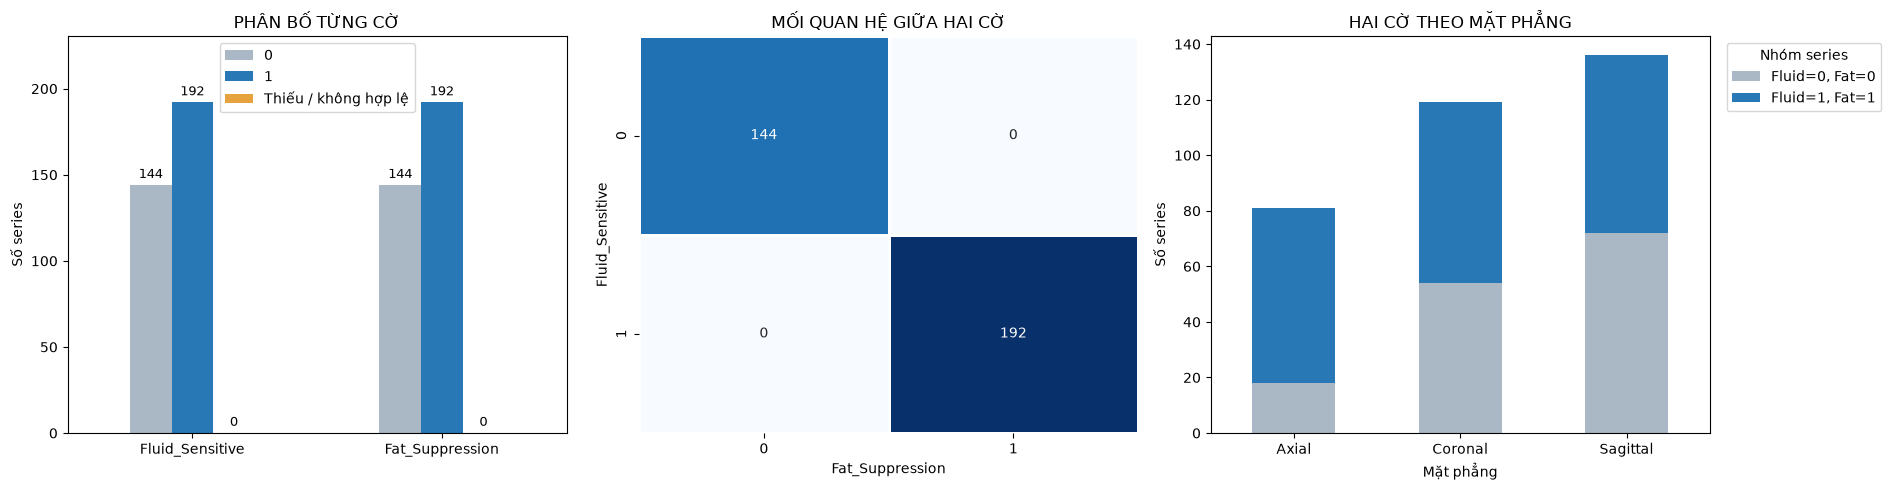


THỐNG KÊ THEO STUDY


,StudyInstanceUID,So_series,So_series_fluid_1,So_series_fat_1,So_series_thieu_fluid,So_series_thieu_fat
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,5,3,3,0,0
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,9,4,4,0,0
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,7,5,5,0,0
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,5,4,4,0,0
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,9,5,5,0,0
5,1.2.826.0.1.3680043.8.498.11548045715264151632...,9,4,4,0,0
6,1.2.826.0.1.3680043.8.498.11557620559191469069...,6,3,3,0,0
7,1.2.826.0.1.3680043.8.498.11771393824519892797...,5,4,4,0,0
8,1.2.826.0.1.3680043.8.498.11851412923016044948...,5,3,3,0,0
9,1.2.826.0.1.3680043.8.498.11915937982684988073...,4,3,3,0,0


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

flags = ["Fluid_Sensitive", "Fat_Suppression"]

df_flags = (
    series_df
    .dropna(subset=["StudyInstanceUID", "SeriesInstanceUID"])
    .drop_duplicates(subset=["StudyInstanceUID", "SeriesInstanceUID"])
    .copy()
)

if df_flags.empty:
    raise ValueError("Không có series để khảo sát.")

# Chuẩn hóa: chỉ chấp nhận 0/1; giá trị khác được giữ là thiếu
for col in flags:
    values = pd.to_numeric(df_flags[col], errors="coerce")
    df_flags[col] = values.where(values.isin([0, 1])).astype("Int64")

# Chuẩn hóa mặt phẳng
df_flags["Plane"] = (
    df_flags["Anatomical_Plane"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({
        "axial": "Axial",
        "coronal": "Coronal",
        "sagittal": "Sagittal"
    })
    .fillna("Khác / thiếu")
)

# 1. Thống kê từng cờ
summary = pd.DataFrame({
    col: [
        int(df_flags[col].eq(0).sum()),
        int(df_flags[col].eq(1).sum()),
        int(df_flags[col].isna().sum())
    ]
    for col in flags
}, index=["0", "1", "Thiếu / không hợp lệ"]).T

summary["Tỷ lệ 1 / có dữ liệu (%)"] = [
    df_flags[col].dropna().eq(1).mean() * 100
    for col in flags
]

print(f"Tổng số series: {len(df_flags)}")
display(summary.round(2))

# 2. Bảng chéo giữa hai cờ: chỉ dùng series có đủ cả hai
valid_pairs = df_flags.dropna(subset=flags)

cross_table = pd.crosstab(
    valid_pairs["Fluid_Sensitive"],
    valid_pairs["Fat_Suppression"]
).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

print(f"\nSeries có đủ hai cờ: {len(valid_pairs)}/{len(df_flags)}")

if not valid_pairs.empty:
    same = valid_pairs["Fluid_Sensitive"].eq(
        valid_pairs["Fat_Suppression"]
    )
    print(f"Hai cờ giống nhau: {same.sum()} series ({same.mean():.1%})")
    print(f"Hai cờ khác nhau: {(~same).sum()} series")

# 3. Gán nhóm kết hợp
def flag_group(row):
    fluid = row["Fluid_Sensitive"]
    fat = row["Fat_Suppression"]

    if pd.isna(fluid) or pd.isna(fat):
        return "Thiếu / không hợp lệ"

    return f"Fluid={int(fluid)}, Fat={int(fat)}"

df_flags["Flag_group"] = df_flags.apply(flag_group, axis=1)

group_order = [
    "Fluid=0, Fat=0",
    "Fluid=0, Fat=1",
    "Fluid=1, Fat=0",
    "Fluid=1, Fat=1",
    "Thiếu / không hợp lệ"
]

plane_order = ["Axial", "Coronal", "Sagittal"]
if df_flags["Plane"].eq("Khác / thiếu").any():
    plane_order.append("Khác / thiếu")

by_plane = pd.crosstab(
    df_flags["Plane"], df_flags["Flag_group"]
).reindex(
    index=plane_order,
    columns=group_order,
    fill_value=0
)

# Bỏ nhóm hoàn toàn không xuất hiện để chú thích gọn hơn
by_plane = by_plane.loc[:, by_plane.sum().gt(0)]

# 4. Vẽ ba biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

summary[["0", "1", "Thiếu / không hợp lệ"]].plot.bar(
    ax=axes[0],
    color=["#AAB7C4", "#2878B5", "#E6A23C"],
    rot=0
)
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=9)

axes[0].set_title("PHÂN BỐ TỪNG CỜ")
axes[0].set_xlabel("")
axes[0].set_ylabel("Số series")
axes[0].margins(y=0.2)

sns.heatmap(
    cross_table,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    ax=axes[1]
)
axes[1].set_title("MỐI QUAN HỆ GIỮA HAI CỜ")
axes[1].set_xlabel("Fat_Suppression")
axes[1].set_ylabel("Fluid_Sensitive")

group_colors = {
    "Fluid=0, Fat=0": "#AAB7C4",
    "Fluid=0, Fat=1": "#E6A23C",
    "Fluid=1, Fat=0": "#36A890",
    "Fluid=1, Fat=1": "#2878B5",
    "Thiếu / không hợp lệ": "#C96E82"
}

by_plane.plot.bar(
    stacked=True,
    ax=axes[2],
    color=[group_colors[col] for col in by_plane.columns],
    rot=0
)
axes[2].set_title("HAI CỜ THEO MẶT PHẲNG")
axes[2].set_xlabel("Mặt phẳng")
axes[2].set_ylabel("Số series")
axes[2].legend(
    title="Nhóm series",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()

output_dir = ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / "fluid_sensitive_fat_suppression.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 5. Khảo sát mỗi study có bao nhiêu series mang cờ 1
study_flags = df_flags.groupby("StudyInstanceUID").agg(
    So_series=("SeriesInstanceUID", "nunique"),
    So_series_fluid_1=("Fluid_Sensitive", lambda s: s.eq(1).sum()),
    So_series_fat_1=("Fat_Suppression", lambda s: s.eq(1).sum()),
    So_series_thieu_fluid=("Fluid_Sensitive", lambda s: s.isna().sum()),
    So_series_thieu_fat=("Fat_Suppression", lambda s: s.isna().sum())
)

print("\nTHỐNG KÊ THEO STUDY")
display(study_flags.reset_index())

study_flags.to_csv(
    output_dir / "fluid_fat_tung_study.csv",
    encoding="utf-8-sig"
)

# Xem các series có hai cờ khác nhau
different = valid_pairs.loc[
    valid_pairs["Fluid_Sensitive"].ne(valid_pairs["Fat_Suppression"])
]

if not different.empty:
    print("\nCÁC SERIES CÓ HAI CỜ KHÁC NHAU")
    columns = [
        "StudyInstanceUID", "SeriesInstanceUID",
        "Plane", "Fluid_Sensitive", "Fat_Suppression"
    ]
    if "SeriesDescription" in different.columns:
        columns.append("SeriesDescription")

    display(different[columns])

In [38]:
# Thống kê số series theo tổ hợp hai cờ trong từng study
pair_columns = {
    "Fluid=1, Fat=1": "So_series_11",
    "Fluid=0, Fat=0": "So_series_00",
    "Fluid=0, Fat=1": "So_series_01",
    "Fluid=1, Fat=0": "So_series_10",
}

pair_counts = pd.crosstab(
    df_flags["StudyInstanceUID"],
    df_flags["Flag_group"]
).reindex(columns=pair_columns.keys(), fill_value=0)
pair_counts.columns = list(pair_columns.values())

study_pair_counts = df_flags.groupby("StudyInstanceUID").agg(
    So_series=("SeriesInstanceUID", "nunique"),
    So_series_thieu_hoac_khong_hop_le=(
        "Flag_group", lambda values: values.eq("Thiếu / không hợp lệ").sum()
    )
 ).join(pair_counts)

valid_pair_counts = (
    df_flags["Flag_group"].isin(pair_columns)
    .groupby(df_flags["StudyInstanceUID"])
    .sum()
 )
assert study_pair_counts[list(pair_columns.values())].sum(axis=1).eq(
    valid_pair_counts
 ).all()

print("SỐ SERIES THEO TỔ HỢP CỜ TRONG TỪNG STUDY")
display(study_pair_counts.reset_index())

study_pair_counts.reset_index().to_csv(
    output_dir / "fluid_fat_tung_study.csv",
    index=False,
    encoding="utf-8-sig"
 )
print("Đã cập nhật: ", output_dir / "fluid_fat_tung_study.csv")

SỐ SERIES THEO TỔ HỢP CỜ TRONG TỪNG STUDY


,StudyInstanceUID,So_series,So_series_thieu_hoac_khong_hop_le,So_series_11,So_series_00,So_series_01,So_series_10
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,5,0,3,2,0,0
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,9,0,4,5,0,0
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,7,0,5,2,0,0
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,5,0,4,1,0,0
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,9,0,5,4,0,0
5,1.2.826.0.1.3680043.8.498.11548045715264151632...,9,0,4,5,0,0
6,1.2.826.0.1.3680043.8.498.11557620559191469069...,6,0,3,3,0,0
7,1.2.826.0.1.3680043.8.498.11771393824519892797...,5,0,4,1,0,0
8,1.2.826.0.1.3680043.8.498.11851412923016044948...,5,0,3,2,0,0
9,1.2.826.0.1.3680043.8.498.11915937982684988073...,4,0,3,1,0,0


Đã cập nhật:  D:\NCKH\RSNA_58_studies\outputs\fluid_fat_tung_study.csv
